In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:

from boulder_statistics.analysis.quick_calculate_LogNormal import LogNormalFittingFunction


fit = LogNormalFittingFunction(dp, LAD_min=0)

In [ ]:
from statsmodels.base.model import GenericLikelihoodModelResults

from boulder_statistics.analysis.fit_params.log_normal_fit_params import LogNormalFitParams


mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
    optimize_params = LogNormalFitParams(mu=-2.302585093, sigma=2),
    verbose = True
)

Running iteration with params [-2.30258509  2.        ]
Running iteration with params [-2.41771435  2.        ]
Running iteration with params [-2.30258509  2.1       ]
Running iteration with params [-2.41771435  1.9       ]
Running iteration with params [-2.47527897  1.8       ]


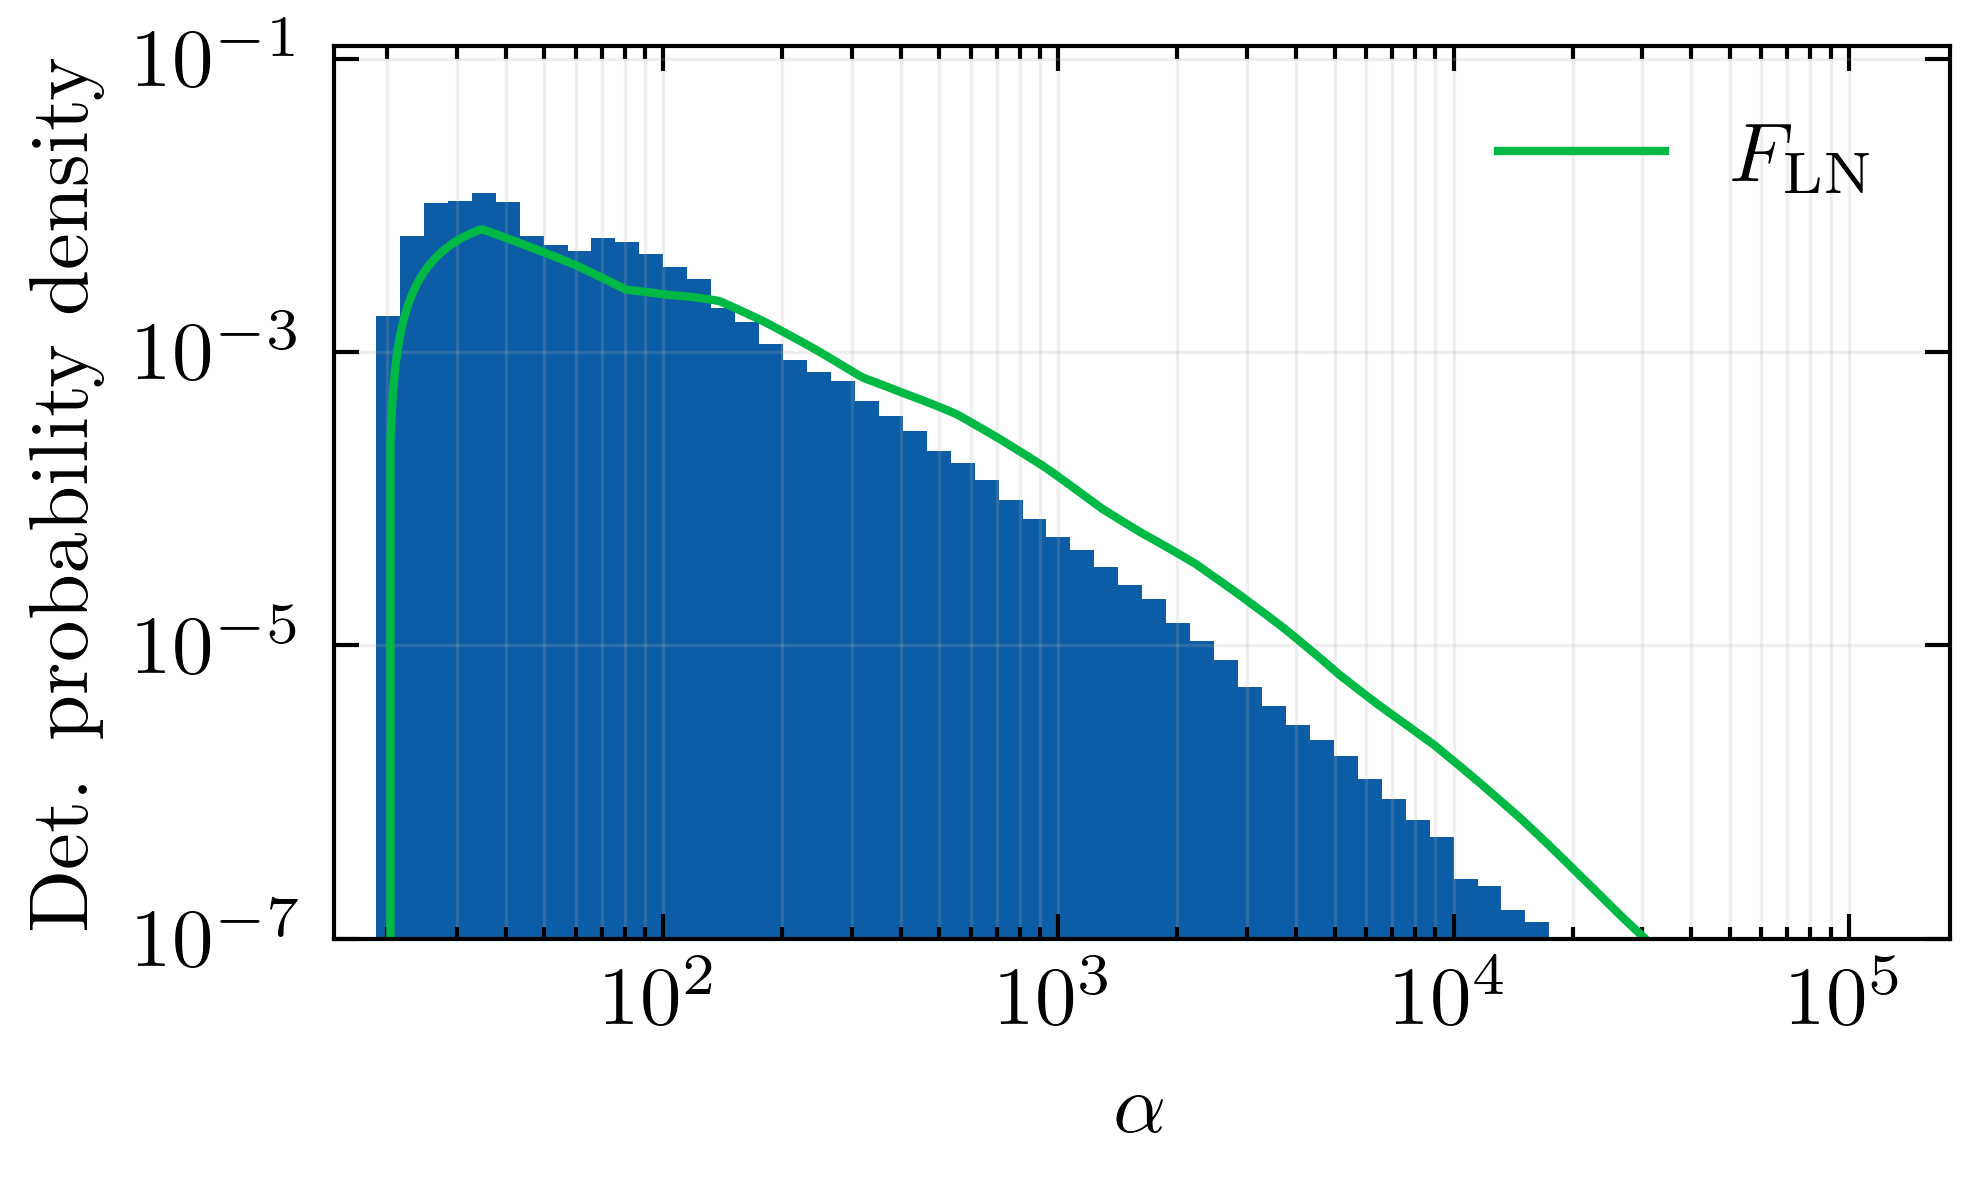

In [ ]:
# 1.6290 0.6006 for LAD min = 2

alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True)

fit_params = LogNormalFitParams(*mle_model.params)
# fit_params = LogNormalFitParams(
#     mu=-2.302585093,
#     sigma=2,
# )
plt.plot(alphas, fit.F_norm(alphas, fit_params), label = r"$F_{\text{LN}}$")

plt.ylim(1e-7, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("overall_fit.png")
plt.show()